In [1]:
import sys
!{sys.executable} -m pip install torch scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip


# Preliminary EDA: Job Salary Prediction Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

# Load data
df = pd.read_csv('data/job_salary_prediction_dataset.csv')
display(df.head())


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


## Basic Information & Missing Values

In [3]:
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)


Dataset Shape: (250000, 10)

Missing Values:
 job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

Data Types:
 job_title             str
experience_years    int64
education_level       str
skills_count        int64
industry              str
company_size          str
location              str
remote_work           str
certifications      int64
salary              int64
dtype: object


## Distribution of Target Variable (Salary)

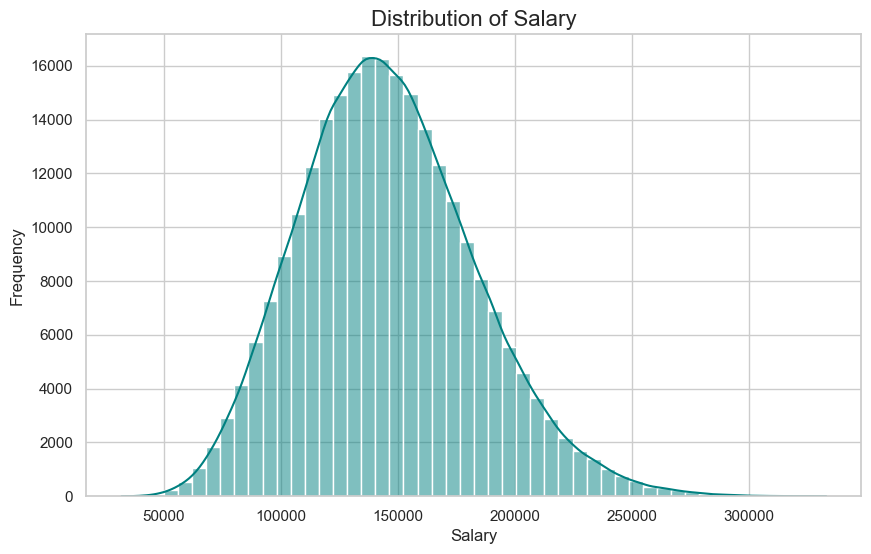

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(df['salary'], bins=50, kde=True, color='teal')
plt.title('Distribution of Salary', fontsize=16)
plt.xlabel('Salary', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()


## Categorical Features vs Salary

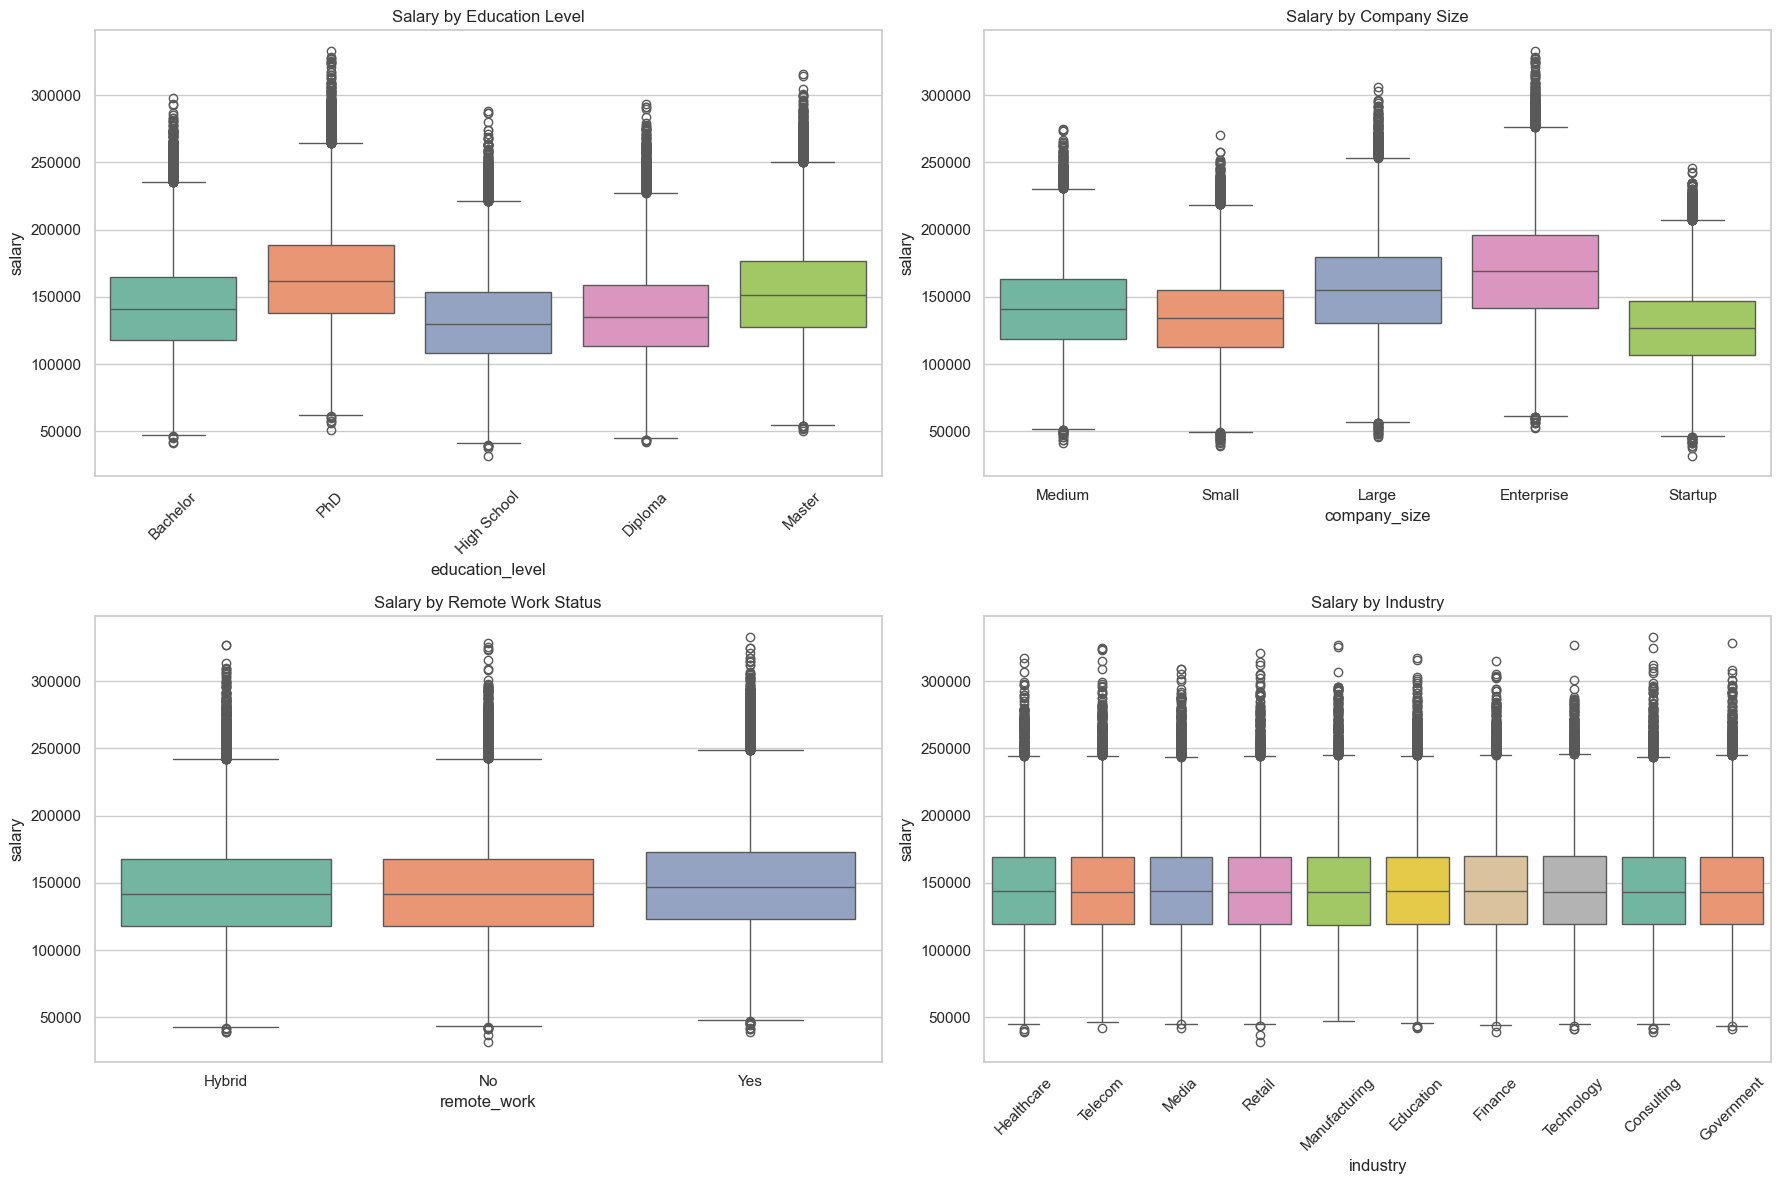

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.boxplot(data=df, x='education_level', y='salary', ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Salary by Education Level')
axes[0,0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='company_size', y='salary', ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Salary by Company Size')

sns.boxplot(data=df, x='remote_work', y='salary', ax=axes[1,0], palette='Set2')
axes[1,0].set_title('Salary by Remote Work Status')

sns.boxplot(data=df, x='industry', y='salary', ax=axes[1,1], palette='Set2')
axes[1,1].set_title('Salary by Industry')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## Numerical Features: Experience & Correlation

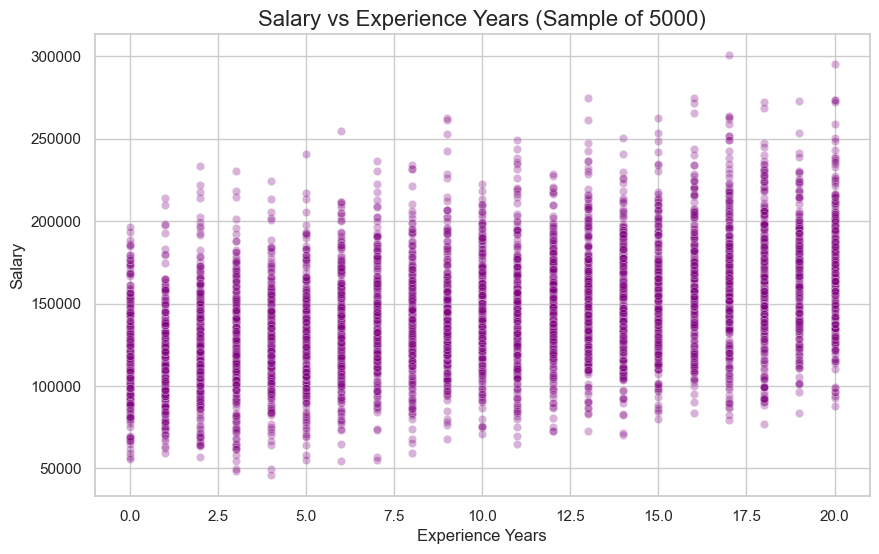

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(5000), x='experience_years', y='salary', alpha=0.3, color='purple')
plt.title('Salary vs Experience Years (Sample of 5000)', fontsize=16)
plt.xlabel('Experience Years')
plt.ylabel('Salary')
plt.show()


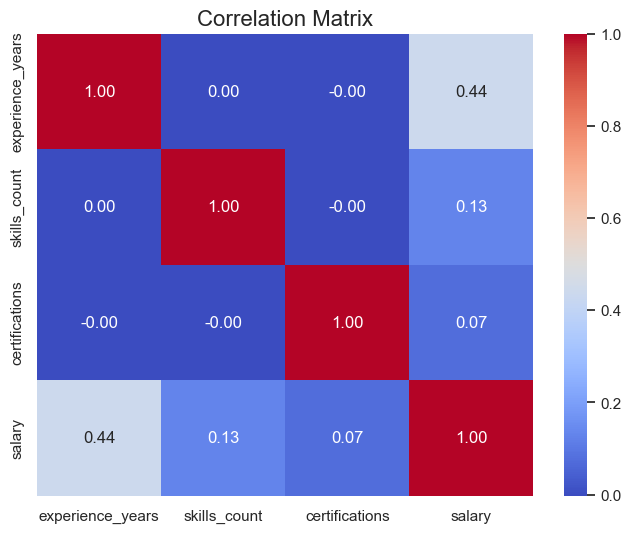

In [7]:
plt.figure(figsize=(8, 6))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix', fontsize=16)
plt.show()


# Data Preprocessing & PyTorch DNN Model
We will prepare the data using Scikit-Learn to one-hot encode categorical features and scale the numerical features before feeding it into a PyTorch Deep Neural Network.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Features and Target
X = df.drop(columns=['salary'])
y = df['salary'].values

# Identify categorical and numerical columns
cat_cols = ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work']
num_cols = ['experience_years', 'skills_count', 'certifications']

# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ])

print("Preprocessing data...")
X_processed = preprocessor.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).view(-1, 1)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test).view(-1, 1)

print(f"Train set shape: {X_train_tensor.shape}")
print(f"Test set shape: {X_test_tensor.shape}")

Preprocessing data...


Train set shape: torch.Size([200000, 42])
Test set shape: torch.Size([50000, 42])


## Two-Phase Grid Search Optimization
**Phase 1**: We test multiple architectures and hyperparameter sets on a 20% random subsample of the training data. This prevents the grid search from taking hours on a laptop CPU.

**Phase 2**: We select the winning configuration and train it fully on the entire dataset.

In [9]:
class DynamicSalaryDNN(nn.Module):
    def __init__(self, input_dim, hidden_layers, dropout_rate):
        super(DynamicSalaryDNN, self).__init__()
        layers = []
        in_dim = input_dim
        for h_dim in hidden_layers:
            layers.append(nn.Linear(in_dim, h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            in_dim = h_dim
        layers.append(nn.Linear(in_dim, 1))
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x)

In [10]:
import itertools

# Phase 1: Rapid Grid Search on 20% subsample of training data
subset_size = int(0.20 * len(X_train_tensor))
indices = torch.randperm(len(X_train_tensor))[:subset_size]

X_train_sub = X_train_tensor[indices]
y_train_sub = y_train_tensor[indices]

train_dataset_sub = TensorDataset(X_train_sub, y_train_sub)
train_loader_sub = DataLoader(train_dataset_sub, batch_size=512, shuffle=True)

# Define Hyperparameter Grid
grid = {
    'hidden_layers': [[128, 64], [256, 128, 64]],
    'lr': [0.01, 0.001],
    'dropout': [0.1, 0.3]
}

keys, values = zip(*grid.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

best_loss = float('inf')
best_params = None

print(f"Starting Grid Search across {len(combinations)} combinations on a {subset_size}-row subsample...")

for idx, params in enumerate(combinations):
    model = DynamicSalaryDNN(input_dim=X_train_sub.shape[1], 
                             hidden_layers=params['hidden_layers'], 
                             dropout_rate=params['dropout'])
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=params['lr'])
    
    # Train for 10 epochs for rapid evaluation
    model.train()
    for epoch in range(10):
        for batch_X, batch_y in train_loader_sub:
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()
            
    # Evaluate on the full test set
    model.eval()
    with torch.no_grad():
        test_preds = model(X_test_tensor)
        val_loss = criterion(test_preds, y_test_tensor).item()
        
    print(f"Config {idx+1}/{len(combinations)} | {params} | Val MSE: {val_loss:,.2f}")
    
    if val_loss < best_loss:
        best_loss = val_loss
        best_params = params

print(f"\nBest Configuration Found: {best_params} with Val MSE: {best_loss:,.2f}")

Starting Grid Search across 8 combinations on a 40000-row subsample...


Config 1/8 | {'hidden_layers': [128, 64], 'lr': 0.01, 'dropout': 0.1} | Val MSE: 489,985,696.00


Config 2/8 | {'hidden_layers': [128, 64], 'lr': 0.01, 'dropout': 0.3} | Val MSE: 485,190,432.00


Config 3/8 | {'hidden_layers': [128, 64], 'lr': 0.001, 'dropout': 0.1} | Val MSE: 5,544,339,456.00


Config 4/8 | {'hidden_layers': [128, 64], 'lr': 0.001, 'dropout': 0.3} | Val MSE: 5,222,537,216.00


Config 5/8 | {'hidden_layers': [256, 128, 64], 'lr': 0.01, 'dropout': 0.1} | Val MSE: 38,227,564.00


Config 6/8 | {'hidden_layers': [256, 128, 64], 'lr': 0.01, 'dropout': 0.3} | Val MSE: 69,656,912.00


Config 7/8 | {'hidden_layers': [256, 128, 64], 'lr': 0.001, 'dropout': 0.1} | Val MSE: 771,628,608.00


Config 8/8 | {'hidden_layers': [256, 128, 64], 'lr': 0.001, 'dropout': 0.3} | Val MSE: 759,976,832.00

Best Configuration Found: {'hidden_layers': [256, 128, 64], 'lr': 0.01, 'dropout': 0.1} with Val MSE: 38,227,564.00


In [11]:
# Phase 2: Full Training
print("Starting Phase 2: Training Best Model on Full Dataset...")
final_model = DynamicSalaryDNN(input_dim=X_train_tensor.shape[1], 
                               hidden_layers=best_params['hidden_layers'], 
                               dropout_rate=best_params['dropout'])

criterion = nn.MSELoss()
optimizer = optim.Adam(final_model.parameters(), lr=best_params['lr'])

full_train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
full_train_loader = DataLoader(full_train_dataset, batch_size=512, shuffle=True)

epochs = 50
train_losses = []

for epoch in range(epochs):
    final_model.train()
    epoch_loss = 0
    for batch_X, batch_y in full_train_loader:
        optimizer.zero_grad()
        predictions = final_model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    avg_loss = epoch_loss / len(full_train_loader)
    train_losses.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss (MSE): {avg_loss:,.2f}")

Starting Phase 2: Training Best Model on Full Dataset...


Epoch 10/50 - Loss (MSE): 155,823,798.61


Epoch 20/50 - Loss (MSE): 155,471,481.27


Epoch 30/50 - Loss (MSE): 154,830,684.62


Epoch 40/50 - Loss (MSE): 153,069,255.84


Epoch 50/50 - Loss (MSE): 153,074,385.80


Final Model Mean Absolute Error (MAE): $4,355.51
Final Model R-squared Score (R2): 0.9787


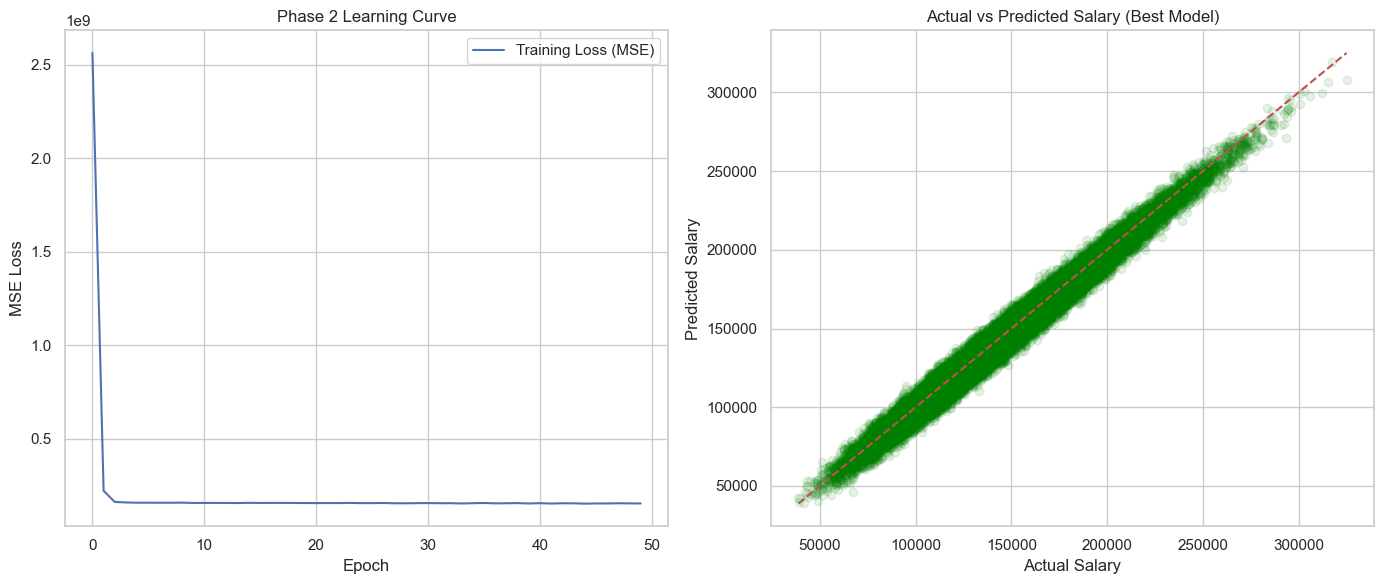

In [12]:
from sklearn.metrics import mean_absolute_error, r2_score

final_model.eval()
with torch.no_grad():
    predictions = final_model(X_test_tensor).numpy()

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Final Model Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Final Model R-squared Score (R2): {r2:.4f}")

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss (MSE)')
plt.title('Phase 2 Learning Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(y_test, predictions, alpha=0.1, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Actual vs Predicted Salary (Best Model)')

plt.tight_layout()
plt.show()


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip



=== Model Architecture Summary ===
Layer (type:depth-idx)                   Output Shape              Param #
DynamicSalaryDNN                         [1, 1]                    --
├─Sequential: 1-1                        [1, 1]                    --
│    └─Linear: 2-1                       [1, 256]                  11,008
│    └─ReLU: 2-2                         [1, 256]                  --
│    └─Dropout: 2-3                      [1, 256]                  --
│    └─Linear: 2-4                       [1, 128]                  32,896
│    └─ReLU: 2-5                         [1, 128]                  --
│    └─Dropout: 2-6                      [1, 128]                  --
│    └─Linear: 2-7                       [1, 64]                   8,256
│    └─ReLU: 2-8                         [1, 64]                   --
│    └─Dropout: 2-9                      [1, 64]                   --
│    └─Linear: 2-10                      [1, 1]                    65
Total params: 52,225
Trainable params:

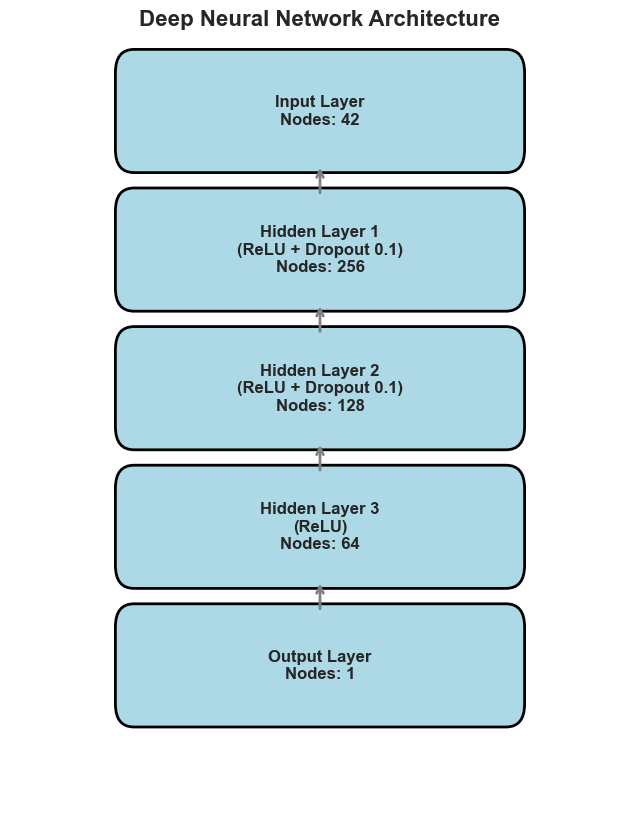

In [13]:
import sys
!{sys.executable} -m pip install torchinfo

from torchinfo import summary
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Print model summary
print("\n=== Model Architecture Summary ===")
print(summary(final_model, input_size=(1, X_train_tensor.shape[1])))

# Create Figure to visualize architecture
fig, ax = plt.subplots(figsize=(8, 10))
ax.axis('off')

# Extract sizes from the final_model
# Architecture: Input -> 256 -> 128 -> 64 -> 1
layer_sizes = [X_train_tensor.shape[1], 256, 128, 64, 1]
layer_names = [
    'Input Layer', 
    'Hidden Layer 1\n(ReLU + Dropout 0.1)', 
    'Hidden Layer 2\n(ReLU + Dropout 0.1)', 
    'Hidden Layer 3\n(ReLU)', 
    'Output Layer'
]

y_start = 0.9
box_height = 0.1
box_width = 0.6

for i, (size, name) in enumerate(zip(layer_sizes, layer_names)):
    y_pos = y_start - i * 0.18
    
    # Draw box
    rect = patches.FancyBboxPatch((0.2, y_pos - box_height/2), box_width, box_height, 
                                  boxstyle="round,pad=0.03", 
                                  edgecolor='black', facecolor='lightblue', lw=2)
    ax.add_patch(rect)
    
    # Draw text
    ax.text(0.5, y_pos, f"{name}\nNodes: {size}", 
            ha='center', va='center', fontsize=12, fontweight='bold')
    
    # Draw arrow to next layer
    if i < len(layer_sizes) - 1:
        ax.annotate('', xy=(0.5, y_pos - box_height/2 - 0.02), 
                    xytext=(0.5, y_pos - box_height/2 - 0.06),
                    arrowprops=dict(arrowstyle="->", lw=2, color='gray'))

plt.title("Deep Neural Network Architecture", fontsize=16, fontweight='bold')
plt.show()
